<a href="https://colab.research.google.com/github/nehasingh913833-gif/basic-ML/blob/main/naive_bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving Iris.csv to Iris.csv
User uploaded file "Iris.csv" with length 5107 bytes


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


df = pd.read_csv('Iris.csv')

feature_names = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
target_names = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']


df["target"] = df["Species"].map({
    "Iris-setosa": 0,
    "Iris-versicolor": 1,
    "Iris-virginica": 2
})








In [ ]:
X = df[feature_names]
y = df['target']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- Data Split ---")
print(f"Shape of training features (X_train): {X_train.shape}")
print(f"Shape of testing features (X_test): {X_test.shape}")
print("\n")

--- Data Split ---
Shape of training features (X_train): (120, 4)
Shape of testing features (X_test): (30, 4)




In [ ]:
nb_model = GaussianNB()


nb_model.fit(X_train, y_train)
print("--- Gaussian Naive Bayes Model has been trained successfully. ---\n")

--- Gaussian Naive Bayes Model has been trained successfully. ---



--- Model Performance Evaluation ---
Accuracy: 1.00
This means the model predicted the correct species for all test samples.

--- Classification Report ---
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30





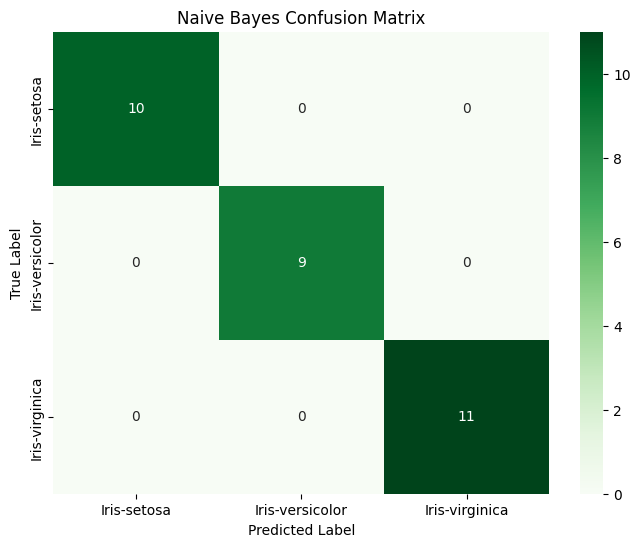

In [ ]:

y_pred = nb_model.predict(X_test)

print("--- Model Performance Evaluation ---")

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("This means the model predicted the correct species for all test samples.\n")

print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=target_names))
print("\n")


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Naive Bayes Confusion Matrix')
plt.show()